In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import sys
import random
import re
import json

# ============================================================
# 1. 고정 경로 설정
# ============================================================

BASE_DIR = Path('/content/drive/MyDrive/먼작귀')

SIDE_PROJECT_DIR = BASE_DIR / 'synthetic_scenarios' / 'side'
LABELER_DIR = BASE_DIR / 'synthetic_scenarios'

COMMON_FILE = SIDE_PROJECT_DIR / 'side_synthetic_shelf_common.py'
LABELER_FILE = LABELER_DIR / 'synthetic_label_exporter.py'

if not COMMON_FILE.exists():
    raise FileNotFoundError(f'측면 공통 py 파일을 찾지 못했습니다: {COMMON_FILE}')

if not LABELER_FILE.exists():
    raise FileNotFoundError(f'라벨 exporter 파일을 찾지 못했습니다: {LABELER_FILE}')

if str(SIDE_PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(SIDE_PROJECT_DIR))

if str(LABELER_DIR) not in sys.path:
    sys.path.insert(0, str(LABELER_DIR))

import side_synthetic_shelf_common as synth
import synthetic_label_exporter as labeler

ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_사이드.png',
    seed=42,
)

print('측면 공통 py:', COMMON_FILE)
print('라벨 exporter:', LABELER_FILE)
print('BASE_DIR:', BASE_DIR)
print('slot 수:', len(ctx['all_slots']))
print('class 수:', len(ctx['class_map']))

측면 공통 py: /content/drive/MyDrive/먼작귀/synthetic_scenarios/side/side_synthetic_shelf_common.py
라벨 exporter: /content/drive/MyDrive/먼작귀/synthetic_scenarios/synthetic_label_exporter.py
BASE_DIR: /content/drive/MyDrive/먼작귀
slot 수: 12
class 수: 38


In [4]:
# ============================================================
# S3 설정 + 저장 경로
# ============================================================

SCENARIO_CODE = 'S3'
SCENARIO_NAME = '열 단위 공백'
NUM_IMAGES = 20
BASE_SEED = 100260

# SAHI 기준 최종 라벨 저장 경로
IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'side' / SCENARIO_CODE.lower()
PRODUCT_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo' / 'side' / SCENARIO_CODE.lower()
SHELF_LIP_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo_seg' / 'side' / SCENARIO_CODE.lower()
JSON_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_json' / 'side' / SCENARIO_CODE.lower()

for d in [IMAGE_DIR, PRODUCT_YOLO_DIR, SHELF_LIP_YOLO_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def get_next_start_index(image_dir, scenario_code):
    image_dir = Path(image_dir)
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3,5}})\.png$')

    max_num = 0

    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)
        if m:
            max_num = max(max_num, int(m.group(1)))

    return max_num + 1


start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None

print('IMAGE_DIR:', IMAGE_DIR)
print('PRODUCT_YOLO_DIR:', PRODUCT_YOLO_DIR)
print('SHELF_LIP_YOLO_DIR:', SHELF_LIP_YOLO_DIR)
print('JSON_DIR:', JSON_DIR)
print('start_idx:', start_idx)

IMAGE_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/images/side/s3
PRODUCT_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo/side/s3
SHELF_LIP_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo_seg/side/s3
JSON_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_json/side/s3
start_idx: 181


[PNG 선택: S_ROW_KEYWORD] 65027 | row_1 | 30_s_24 | 65027_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 15088 | row_1 | 30_s_24 | 15088_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35828 | row_1 | 30_s_23 | 35828_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 20186 | row_2 | 30_s_23 | 20186_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35763 | row_2 | 30_s_23 | 35763_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10170 | row_2 | 30_s_23 | 10170_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10098 | row_3 | 30_s_24 | 10098_30_s_24_sam_object_crop.png
[PNG 선택: FORCE_KEYWORD] 25425 | row_3 | 30_s_21 | 25425_30_s_21_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10160 | row_3 | 30_s_24 | 10160_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 65327 | row_4 | 30_s_24 | 65327_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 75061 | row_4 | 30_s_24 | 75061_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35872 | row_4 | 30_s_24 | 35872_30_s_24_sam_object_c

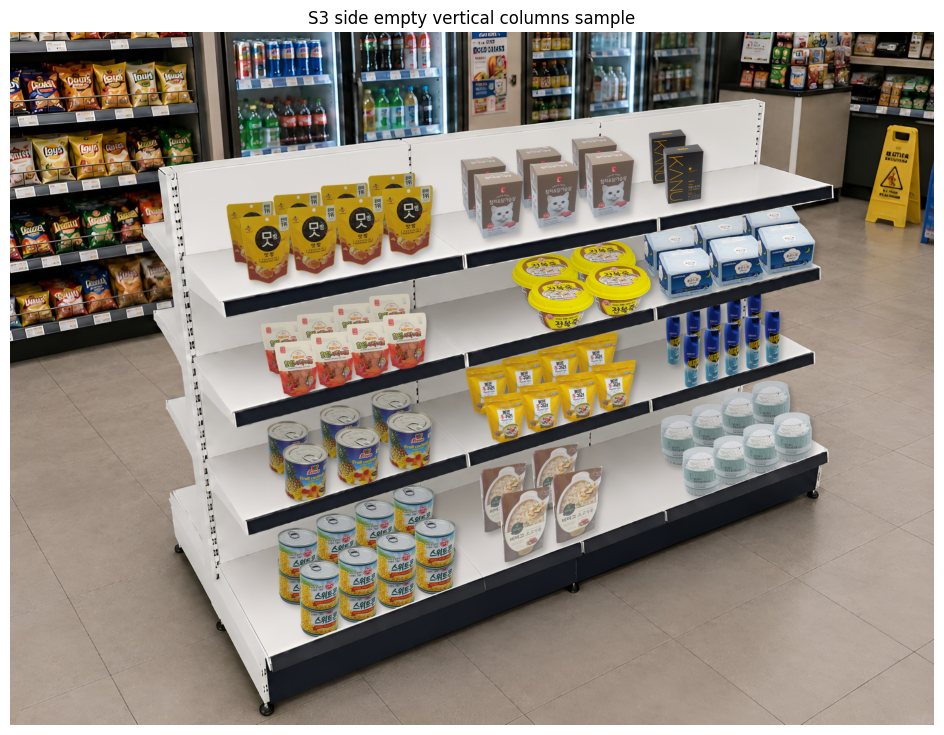

In [5]:
# ============================================================
# S3 측면 합성 + 이미지/라벨 저장
# ============================================================

start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None


def sample_nonempty_subset(
    items,
    prob_range=(0.10, 0.35),
    keep_at_least_one_unselected=False,
):
    """
    전체 후보 중 일부를 랜덤 선택.
    하나도 선택되지 않으면 최소 1개 선택.
    keep_at_least_one_unselected=True이면 전체가 다 선택되지 않도록 1개는 남김.
    """
    items = list(items)

    if len(items) == 0:
        return []

    p = random.uniform(*prob_range)
    selected = [item for item in items if random.random() < p]

    if len(selected) == 0:
        selected = [random.choice(items)]

    if keep_at_least_one_unselected and len(items) > 1 and len(selected) == len(items):
        drop_one = random.choice(selected)
        selected = [item for item in selected if item != drop_one]

        if len(selected) == 0:
            selected = [random.choice(items)]

    return selected


def get_physical_column_count(target):
    """
    S3에서 말하는 '열' 개수 계산.

    normal 상품:
    - normal_front_qty가 곧 열 개수

    can_stack 상품:
    - 8개/12개여도 실제 가로 열은 4열
    - 예: 런천미트 8개 = 4열 x 2단
    - 예: 스팸 12개 = 4열 x 3단
    """
    product_id = str(target['target_product_id'])
    normal_qty = int(target['normal_front_qty'])

    if synth.is_stack_can_product(product_id):
        cols, layers = synth.split_can_stack_grid(normal_qty, product_id)
        return int(cols)

    return int(normal_qty)


def columns_to_missing_indices(target, target_cols):
    """
    선택된 열 번호를 실제 front_missing_indices / back_missing_indices로 변환.

    normal 상품:
    - 열 index = 상품 index

    can_stack 상품:
    - 같은 열의 모든 단을 제거해야 '열 단위 공백'이 됨.
    - 예: 4열 x 2단에서 col=1 제거
      -> index 1, 5 제거
    """
    product_id = str(target['target_product_id'])
    normal_qty = int(target['normal_front_qty'])

    target_cols = sorted(set(int(c) for c in target_cols))

    if synth.is_stack_can_product(product_id):
        cols, layers = synth.split_can_stack_grid(normal_qty, product_id)

        missing_indices = []

        for layer in range(layers):
            for col in target_cols:
                idx = layer * cols + col

                if 0 <= idx < normal_qty:
                    missing_indices.append(idx)

        return sorted(set(missing_indices))

    return target_cols


for image_idx in range(NUM_IMAGES):
    seed = BASE_SEED + image_idx

    random.seed(seed)
    synth.reset_random_seed(seed)

    # 이미지마다 context를 새로 만들어야 상품 조합이 seed마다 바뀜
    ctx = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_사이드.png',
        seed=seed,
    )

    # 1. 정상 진열 slot_plan 생성
    slot_plan = synth.make_normal_slot_plan(ctx)

    # 2. S3 대상 슬롯 랜덤 선택
    # S3는 '열 단위 공백'이므로 물리적 열이 2개 이상인 슬롯만 후보
    candidate_slot_ids = [
        slot_id
        for slot_id, target in slot_plan.items()
        if get_physical_column_count(target) > 1
    ]

    selected_slot_ids = sample_nonempty_subset(
        candidate_slot_ids,
        prob_range=(0.05, 0.30)
    )

    s3_logs = []

    # 3. 선택된 슬롯은 열 단위 공백 처리
    for slot_id in selected_slot_ids:
        target = slot_plan[slot_id]

        normal_front_qty = int(target['normal_front_qty'])
        normal_back_qty = int(target['normal_back_qty'])

        physical_col_count = get_physical_column_count(target)
        all_cols = list(range(physical_col_count))

        # 슬롯마다 비울 열을 랜덤 선택
        # 전체 열을 다 비우면 S4와 비슷해지므로 최소 1열은 남김
        target_cols = sorted(
            sample_nonempty_subset(
                all_cols,
                prob_range=(0.20, 0.65),
                keep_at_least_one_unselected=True,
            )
        )

        front_missing_indices = columns_to_missing_indices(target, target_cols)
        back_missing_indices = columns_to_missing_indices(target, target_cols)

        missing_qty = len(front_missing_indices) + len(back_missing_indices)

        target.update({
            'scenario_code': SCENARIO_CODE,
            'scenario_name': SCENARIO_NAME,

            # 라벨 exporter에서 S3로 인식되도록 action 명확히 지정
            'action': 'empty_column',
            'list_up': True,
            'final_status': '보충 필요 / 발주 필요',

            # 위치 기준은 정상 수량 그대로 유지
            'display_qty': normal_front_qty,
            'back_display_qty': normal_back_qty,

            # S3 핵심:
            # 선택된 열을 앞줄/뒷줄 모두에서 제거
            'front_missing_indices': front_missing_indices,
            'back_missing_indices': back_missing_indices,
            'back_visible_indices': None,
            'extra_misplaced_items': [],

            'missing_qty': missing_qty,
            'reduced_front_qty': normal_front_qty - len(front_missing_indices),

            # 원래 선택된 물리적 열 번호
            'target_column_index': target_cols,
            'physical_column_count': physical_col_count,

            'is_misplaced': False,
        })

        s3_logs.append({
            'slot_id': slot_id,
            'category': target['category'],
            'product_id': target['target_product_id'],
            'product_name': target['target_product_name'],
            'normal_front_qty': normal_front_qty,
            'normal_back_qty': normal_back_qty,
            'physical_column_count': physical_col_count,
            'target_column_index': target_cols,
            'front_missing_indices': front_missing_indices,
            'back_missing_indices': back_missing_indices,
            'missing_qty': missing_qty,
            'rule': 'selected physical columns removed from both front and back rows',
        })

    # 4. 선택되지 않은 슬롯은 정상 유지
    for slot_id, target in slot_plan.items():
        if slot_id not in selected_slot_ids:
            normal_front_qty = int(target['normal_front_qty'])
            normal_back_qty = int(target['normal_back_qty'])

            target.update({
                'scenario_code': SCENARIO_CODE,
                'scenario_name': SCENARIO_NAME,
                'action': 'normal',
                'list_up': False,
                'final_status': '정상',

                'display_qty': normal_front_qty,
                'back_display_qty': normal_back_qty,

                'front_missing_indices': [],
                'back_missing_indices': [],
                'back_visible_indices': None,
                'extra_misplaced_items': [],

                'missing_qty': 0,
                'reduced_front_qty': normal_front_qty,
                'target_column_index': None,
                'physical_column_count': get_physical_column_count(target),

                'is_misplaced': False,
            })

    # 5. 렌더링
    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx,
        slot_plan=slot_plan,
        seed=seed
    )

    # 6. 저장 파일명
    file_no = start_idx + image_idx

    save_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.png'
    yolo_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.txt'
    json_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.json'

    save_path = IMAGE_DIR / save_name
    product_yolo_path = PRODUCT_YOLO_DIR / yolo_name
    shelf_lip_yolo_path = SHELF_LIP_YOLO_DIR / yolo_name
    json_path = JSON_DIR / json_name

    # 7. 이미지 + SAHI 기준 라벨 3종 저장
    label_result = labeler.save_sahi_labels(
        result=result,
        objects=objects,
        slot_labels=slot_labels,
        ctx=ctx,
        scenario_code=SCENARIO_CODE,
        scenario_name=SCENARIO_NAME,
        image_path=save_path,
        product_yolo_path=product_yolo_path,
        shelf_lip_yolo_path=shelf_lip_yolo_path,
        slot_json_path=json_path,
        seed=seed,
        view='side',
    )

    saved_paths.append(save_path)
    last_result = result

    generation_logs.append({
        'file_name': save_name,
        'seed': seed,
        'scenario_code': SCENARIO_CODE,
        'scenario_name': SCENARIO_NAME,
        'n_targets': len(s3_logs),
        'targets': s3_logs,
        'n_objects': len(objects),
        'n_slots': len(slot_labels),
        'image_path': str(save_path),
        'product_yolo_path': str(product_yolo_path),
        'shelf_lip_yolo_path': str(shelf_lip_yolo_path),
        'json_path': str(json_path),
        'label_result': label_result,
    })

    if (image_idx + 1) % 20 == 0:
        print(f'[{image_idx + 1}/{NUM_IMAGES}] 생성 완료:', save_name)

print('S3 생성 완료')
print(f'총 생성 수: {len(saved_paths)}장')
print('이미지 저장 폴더:', IMAGE_DIR)
print('상품 YOLO 저장 폴더:', PRODUCT_YOLO_DIR)
print('선반 앞턱 YOLO-seg 저장 폴더:', SHELF_LIP_YOLO_DIR)
print('slot_state JSON 저장 폴더:', JSON_DIR)

print('처음 5개 파일:')
for p in saved_paths[:5]:
    print('-', p.name)

print('마지막 이미지:', saved_paths[-1])
synth.show_image(last_result, title=f'{SCENARIO_CODE} side empty vertical columns sample')